In [1]:
import pandas as pd

geo_df = pd.read_excel("GEOPOLYMER_CONCRETE_24_2_24 copy.xlsx", header=[0,1,2,3])
light_df = pd.read_excel("LIGHTWEIGHT_CONCRETE.xlsx", header=[0,1,2])

In [2]:
geo_df.head()

,Unnamed: 0_level_0,Unnamed: 1_level_0,Unnamed: 2_level_0,Unnamed: 3_level_0,Unnamed: 4_level_0,Unnamed: 5_level_0,Unnamed: 6_level_0,Unnamed: 7_level_0,Unnamed: 8_level_0,Unnamed: 9_level_0,Unnamed: 10_level_0,Harden Properties
,S.No,Author/s,MIXED,INPUTS,INPUTS,INPUTS,INPUTS,INPUTS,INPUTS,INPUTS,INPUTS,OUTPUT
,Unnamed: 0_level_2,Unnamed: 1_level_2,Number,Binders (kg/m3),Extra Water (kg/m3),Alkaline Solution (Kg/m3),Molarity of mix,FA (kg/m3),CA (kg/m3),Age (days),Curing temperature (Degree Celsius),Compressive Strenght (MPa)
,Unnamed: 0_level_3,Unnamed: 1_level_3,Unnamed: 2_level_3,Unnamed: 3_level_3,Unnamed: 4_level_3,Unnamed: 5_level_3,Unnamed: 6_level_3,Unnamed: 7_level_3,Unnamed: 8_level_3,Unnamed: 9_level_3,Unnamed: 10_level_3,Unnamed: 11_level_3
0,1.0,"Vora et al., 2013",1,428.0,43.0,171.0,14.0,630.0,1170.0,1.0,75.0,30.0
1,NaN,NaN,2,444.0,43.0,155.0,14.0,630.0,1170.0,1.0,75.0,30.0
2,NaN,NaN,3,428.0,43.0,171.0,14.0,630.0,1170.0,1.0,75.0,40.0
3,NaN,NaN,4,428.0,43.0,171.0,14.0,630.0,1170.0,1.0,75.0,28.0
4,NaN,NaN,5,428.0,43.0,171.0,14.0,630.0,1170.0,2.0,75.0,32.0


In [3]:
light_df.head()

S. No                  Authors Input Variables           \
  Unnamed: 0_level_1       Unnamed: 1_level_1          Binder Pozzolan   
  Unnamed: 0_level_2       Unnamed: 1_level_2         (kg/m3)  (kg/m3)   
0                  1  Tikalsky., et al., 2004           420.0      0.0   
1                  2                      NaN           411.0      0.0   
2                  3                      NaN           149.0    302.0   
3                  4                      NaN           311.0      0.0   
4                  5                      NaN            57.0    268.0   

                                                                           \
  Fine aggregate   Water Foaming agent Measured Density Period of Testing   
         (kg/m3) (kg/m3)       (kg/m3)          (kg/m3)            (Days)   
0            0.0   168.0          39.4            629.0                28   
1            0.0   186.0          38.5            631.0                28   
2            0.0   190.0          35.8            678.0                28   
3            0.0   141.0          44.3            497.0                28   
4          885.0   163.0          20.0           1396.0                28   

      Output Variables  
  Compressive Strength  
                 (MPa)  
0                 1.77  
1                 2.07  
2                 1.09  
3                 0.71  
4                 0.25

In [4]:
geo_df = geo_df[pd.to_numeric(geo_df.iloc[:, 2], errors='coerce').notnull()]

geo_df = geo_df.dropna(how='all', axis=1)

print(f"Cleaned dataset shape: {geo_df.shape}")

geo_df = geo_df.dropna(subset=[geo_df.columns[3]])

geo_df.tail()

Cleaned dataset shape: (2100, 12)


,Unnamed: 0_level_0,Unnamed: 1_level_0,Unnamed: 2_level_0,Unnamed: 3_level_0,Unnamed: 4_level_0,Unnamed: 5_level_0,Unnamed: 6_level_0,Unnamed: 7_level_0,Unnamed: 8_level_0,Unnamed: 9_level_0,Unnamed: 10_level_0,Harden Properties
,S.No,Author/s,MIXED,INPUTS,INPUTS,INPUTS,INPUTS,INPUTS,INPUTS,INPUTS,INPUTS,OUTPUT
,Unnamed: 0_level_2,Unnamed: 1_level_2,Number,Binders (kg/m3),Extra Water (kg/m3),Alkaline Solution (Kg/m3),Molarity of mix,FA (kg/m3),CA (kg/m3),Age (days),Curing temperature (Degree Celsius),Compressive Strenght (MPa)
,Unnamed: 0_level_3,Unnamed: 1_level_3,Unnamed: 2_level_3,Unnamed: 3_level_3,Unnamed: 4_level_3,Unnamed: 5_level_3,Unnamed: 6_level_3,Unnamed: 7_level_3,Unnamed: 8_level_3,Unnamed: 9_level_3,Unnamed: 10_level_3,Unnamed: 11_level_3
2082,NaN,NaN,2084,460.0,32.0,180.0,12.0,512.0,1181.0,90.0,27.0,45.57
2083,NaN,NaN,2085,520.0,32.0,180.0,12.0,465.0,1181.0,90.0,27.0,71.27
2084,NaN,NaN,2086,520.0,32.0,180.0,12.0,465.0,1181.0,90.0,27.0,64.71
2085,NaN,NaN,2087,520.0,32.0,180.0,12.0,465.0,1181.0,90.0,27.0,58.81
2086,NaN,NaN,2088,520.0,32.0,180.0,12.0,465.0,1181.0,90.0,27.0,46.35


In [5]:
geo_df.columns = ["s.no", "authors", "number", "binder", "extra water", "alkaline solution", "molarity of mix", "fine aggregate", "coarse aggregate", "age", "curing temperature", "compressive strength"]

geo_df.columns

Index(['s.no', 'authors', 'number', 'binder', 'extra water',
       'alkaline solution', 'molarity of mix', 'fine aggregate',
       'coarse aggregate', 'age', 'curing temperature',
       'compressive strength'],
      dtype='object')

In [6]:
geo_df.drop_duplicates(inplace=True)

geo_df.duplicated().sum()

np.int64(0)

In [7]:
light_df.columns = ["s.no", "authors", "binder", "pozzolan", "fine aggregate", "water", "foaming agent", "density", "age", "compressive strength"]

light_df.columns

Index(['s.no', 'authors', 'binder', 'pozzolan', 'fine aggregate', 'water',
       'foaming agent', 'density', 'age', 'compressive strength'],
      dtype='object')

In [8]:
light_df.drop_duplicates(inplace=True)

light_df.duplicated().sum()

np.int64(0)

In [9]:
light_df.isnull().sum()

s.no                      0
authors                 984
binder                    0
pozzolan                406
fine aggregate            0
water                     0
foaming agent             0
density                   0
age                       0
compressive strength      0
dtype: int64

In [10]:
# removal of the unnessary columns

geo_df = geo_df.iloc[:, 3:]
light_df = light_df.iloc[:, 2:]


In [11]:
light_df.isnull().sum()

binder                    0
pozzolan                406
fine aggregate            0
water                     0
foaming agent             0
density                   0
age                       0
compressive strength      0
dtype: int64

In [12]:
geo_df.isnull().sum()

binder                  0
extra water             0
alkaline solution       0
molarity of mix         0
fine aggregate          0
coarse aggregate        0
age                     0
curing temperature      0
compressive strength    0
dtype: int64

In [13]:
# zero imputation of the missing values in the datasets

light_df.fillna(0, inplace=True)

light_df.isnull().sum()

binder                  0
pozzolan                0
fine aggregate          0
water                   0
foaming agent           0
density                 0
age                     0
compressive strength    0
dtype: int64

In [14]:
geo_df.columns

Index(['binder', 'extra water', 'alkaline solution', 'molarity of mix',
       'fine aggregate', 'coarse aggregate', 'age', 'curing temperature',
       'compressive strength'],
      dtype='object')

In [15]:
light_df.columns

Index(['binder', 'pozzolan', 'fine aggregate', 'water', 'foaming agent',
       'density', 'age', 'compressive strength'],
      dtype='object')

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_dataset(df, dataset_name):
    print(f"--- Exploratory Data Analysis for {dataset_name} ---")
    
    plt.figure(figsize=(10, 8))
    
    target = 'compressive strength'
    if target in df.columns:
        features = [col for col in df.columns if col != target]
        fig, axes = plt.subplots(nrows=int(len(features)/3) + 1, ncols=3, figsize=(15, 12))
        axes = axes.flatten()
        
        for i, col in enumerate(features):
            sns.scatterplot(data=df, x=col, y=target, ax=axes[i], alpha=0.6)
            axes[i].set_title(f'{col} vs {target}')
            
        for j in range(i + 1, len(axes)):
            fig.delaxes(axes[j])
            
        plt.tight_layout()
        plt.show()

    plt.figure(figsize=(15, 8))
    sns.boxplot(data=df, orient="h", palette="Set2")
    plt.title(f'Boxplots (Outlier Detection) - {dataset_name}')
    plt.tight_layout()
    plt.show()
    

    corr_matrix = df.corr()
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
    plt.title(f'Correlation Matrix - {dataset_name}')
    plt.show()
    
    
    num_cols = len(df.columns)
    df.hist(bins=30, figsize=(15, 12), layout=(int(num_cols/3) + 1, 3))
    plt.suptitle(f'Histograms (Distributions) - {dataset_name}', fontsize=16)
    plt.tight_layout()
    plt.show()


original number of rows:  2087
Geopolymer after cleaning: 1691 rows

--- Exploratory Data Analysis for Geopolymer Concrete (geo_df) ---


<Figure size 1000x800 with 0 Axes>

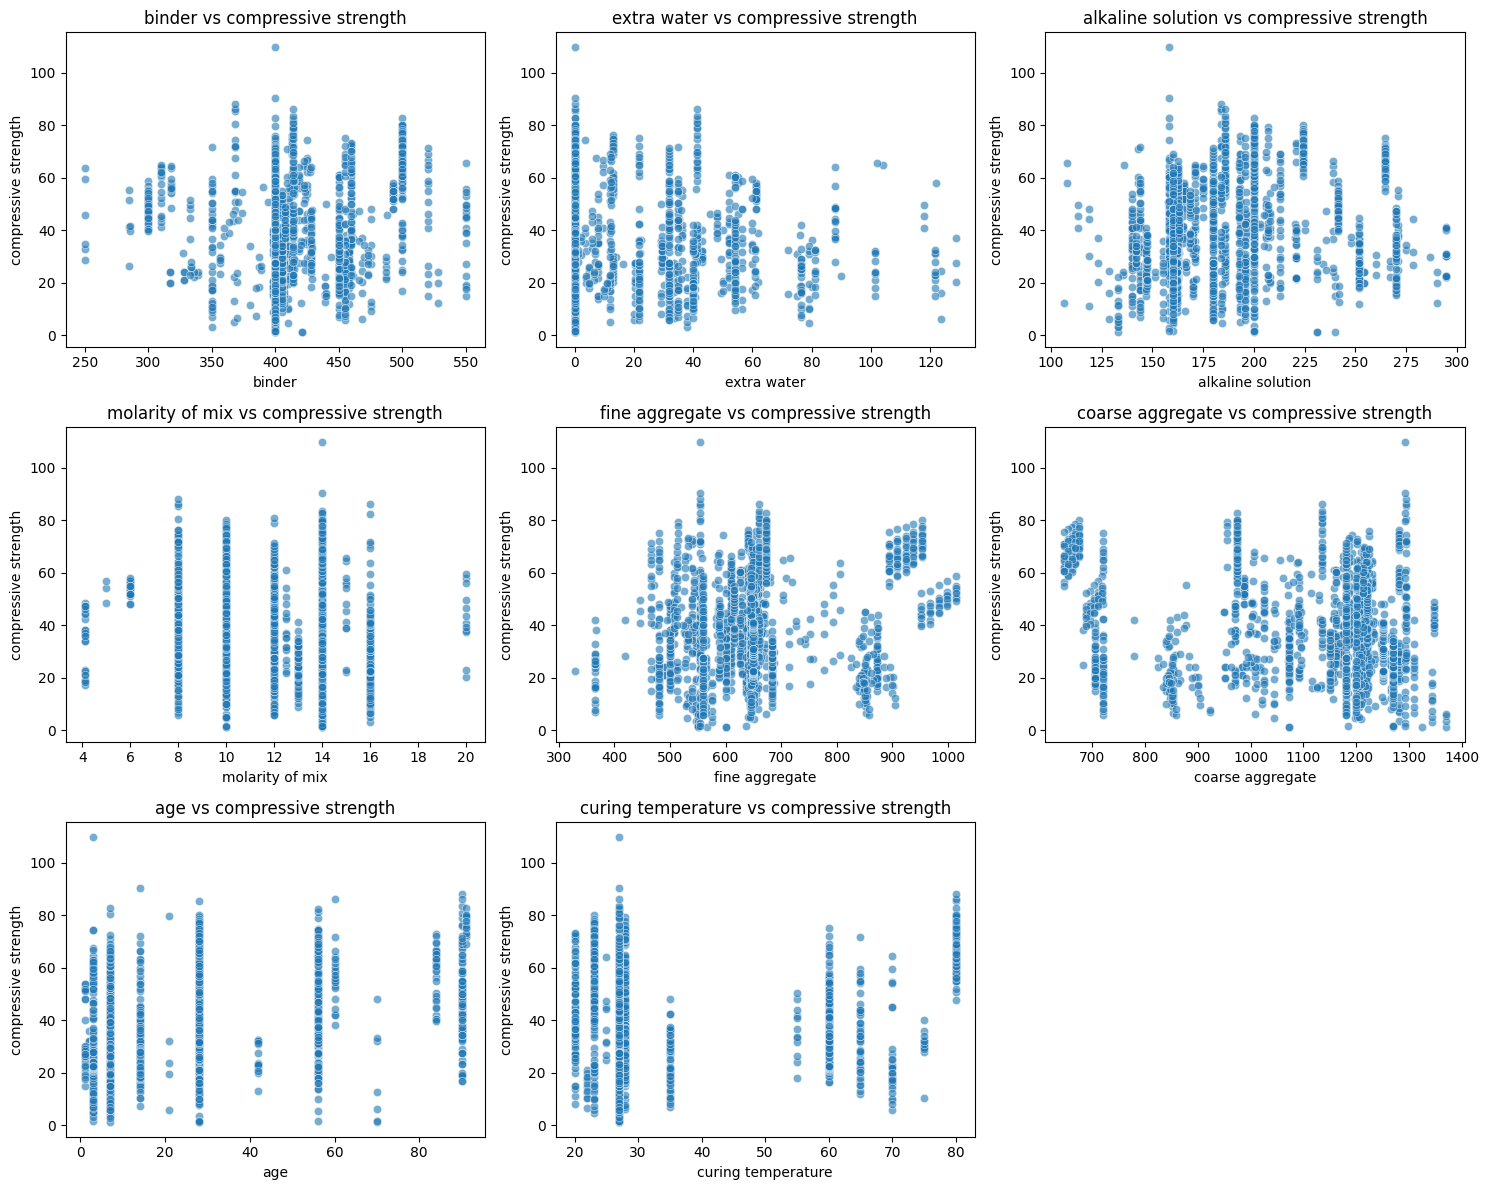

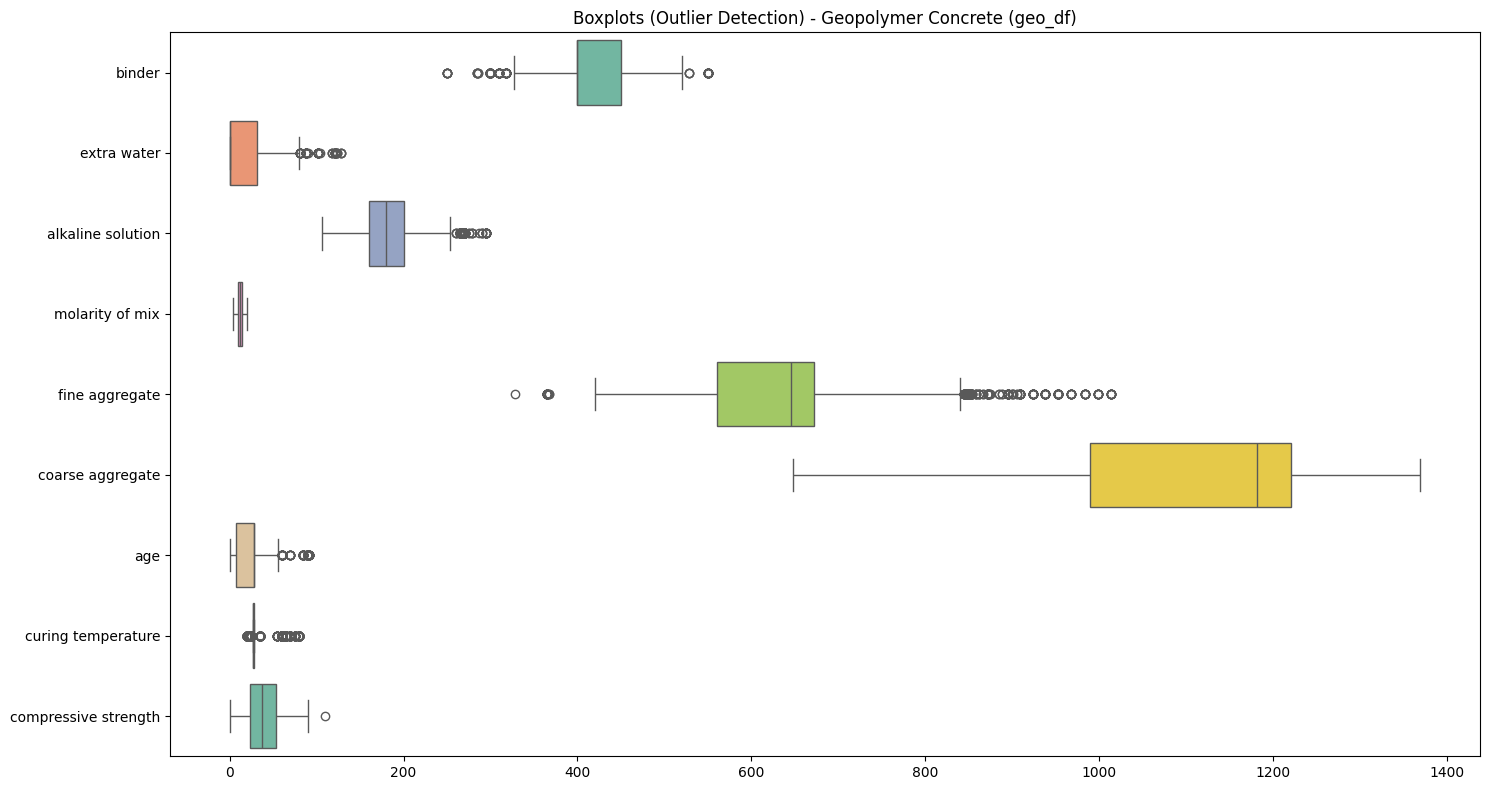

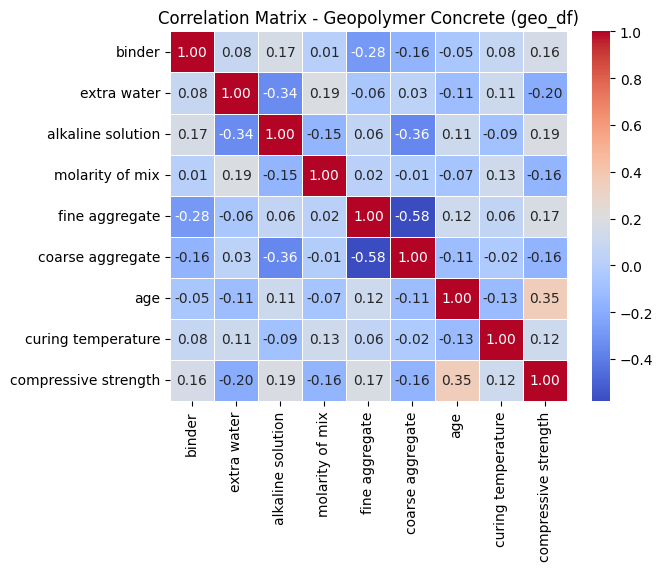

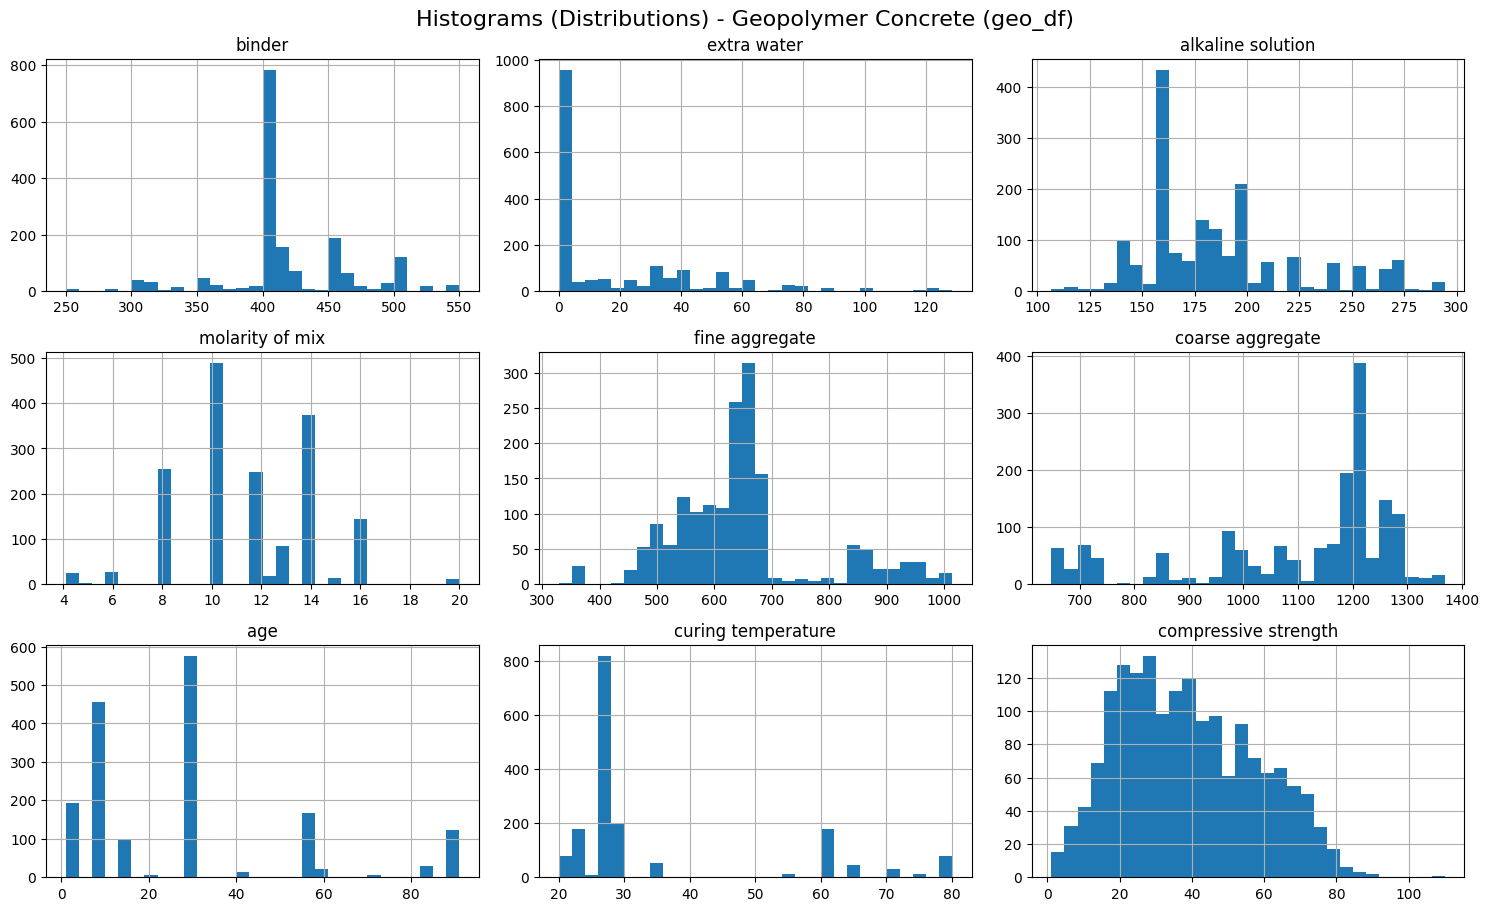

In [17]:
clean_geo_df = geo_df.copy()
print("original number of rows: ", len(clean_geo_df))

numeric_geo = ['binder', 'extra water', 'alkaline solution', 'molarity of mix',
               'fine aggregate', 'coarse aggregate', 'age', 'curing temperature',
               'compressive strength', 'water']

clean_geo_df = clean_geo_df[clean_geo_df['age'] <= 175] 
clean_geo_df = clean_geo_df[clean_geo_df['extra water'] < 130]
clean_geo_df = clean_geo_df[(clean_geo_df['alkaline solution'] <= 300) & (clean_geo_df['alkaline solution'] > 100)]
clean_geo_df = clean_geo_df[clean_geo_df['molarity of mix'] <= 20]         
clean_geo_df = clean_geo_df[clean_geo_df['binder'] < 600]
clean_geo_df = clean_geo_df[clean_geo_df['compressive strength'] > 0]
clean_geo_df = clean_geo_df[clean_geo_df['curing temperature'] < 90]
clean_geo_df = clean_geo_df[clean_geo_df['coarse aggregate'] < 1400]
clean_geo_df = clean_geo_df[clean_geo_df['fine aggregate'] < 1100]

print(f"Geopolymer after cleaning: {len(clean_geo_df)} rows\n")

analyze_dataset(clean_geo_df, "Geopolymer Concrete (geo_df)")

Lightweight original: 1006 rows
Lightweight after cleaning: 912 rows

--- Exploratory Data Analysis for Lightweight Concrete (light_df) ---


<Figure size 1000x800 with 0 Axes>

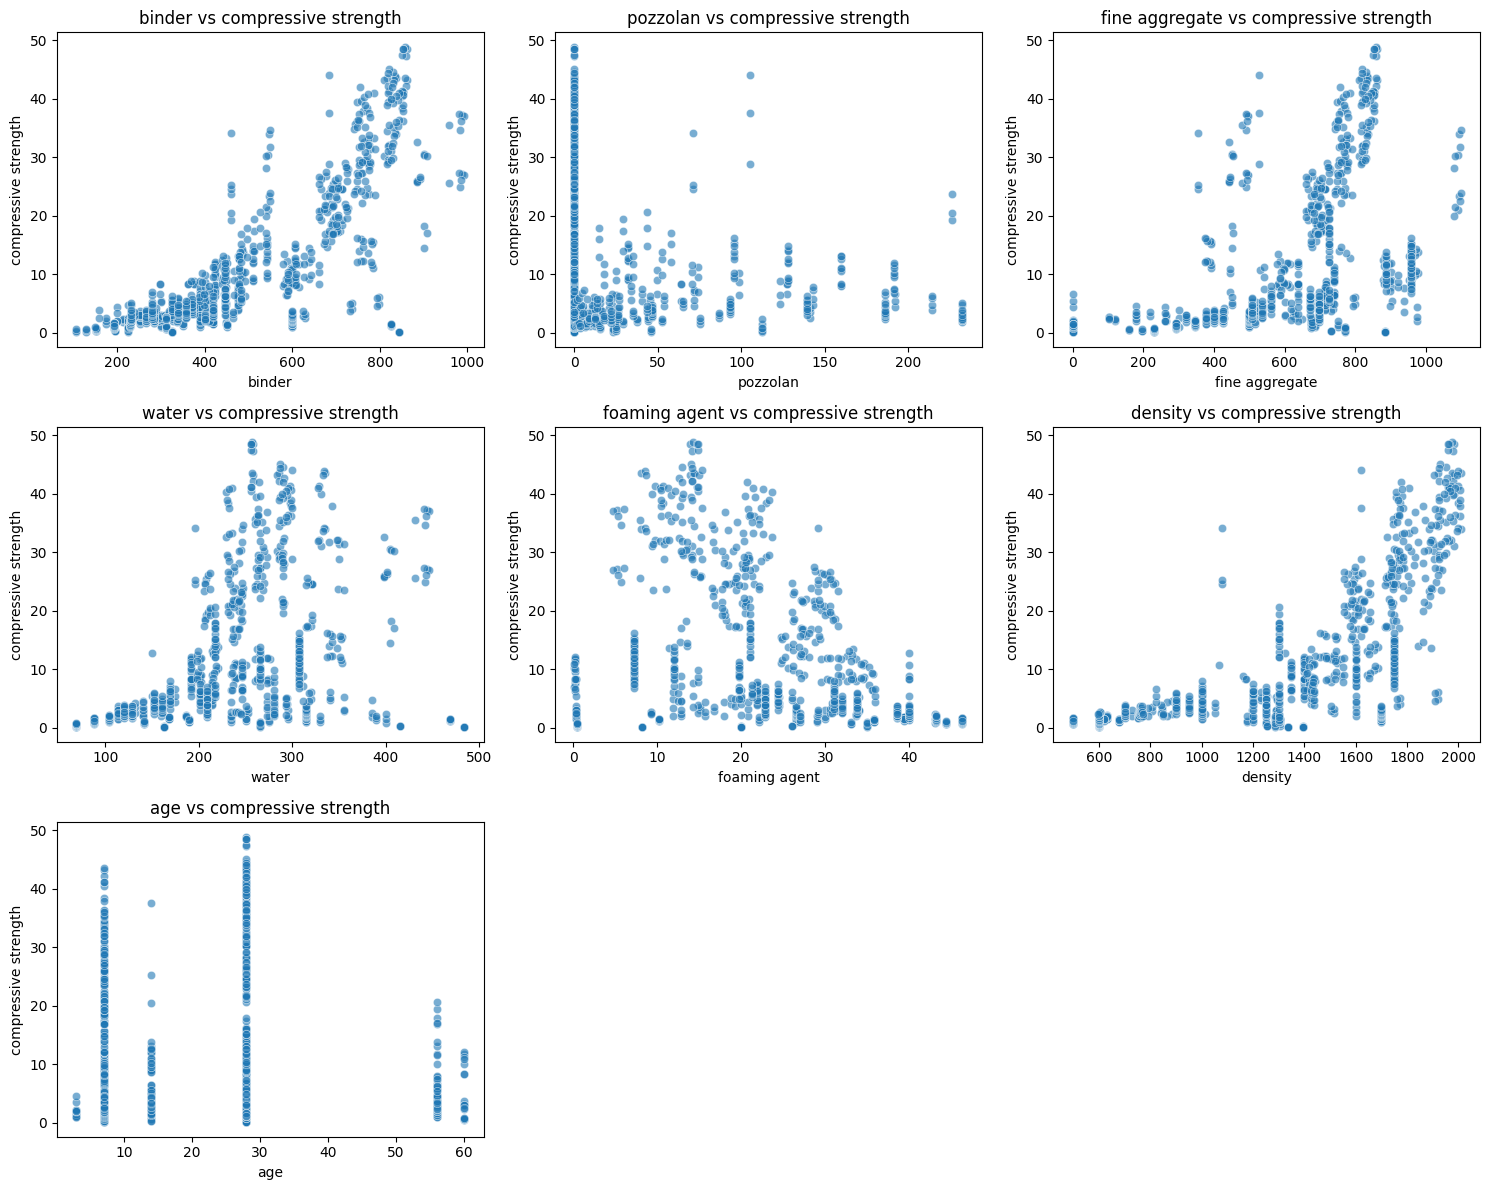

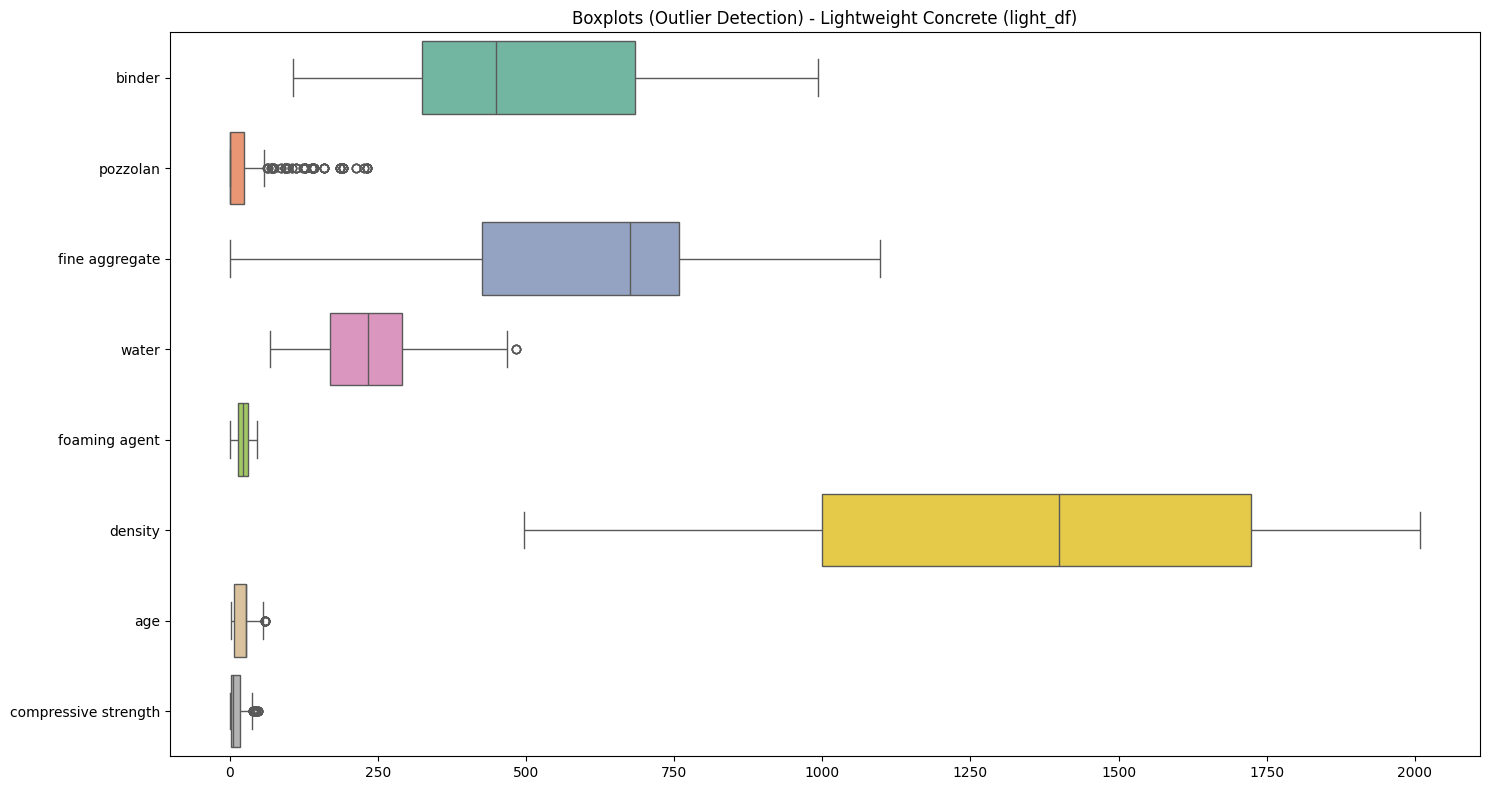

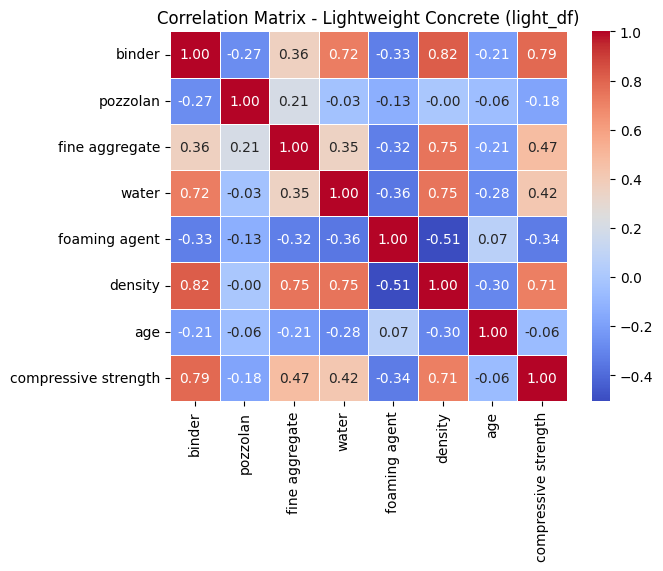

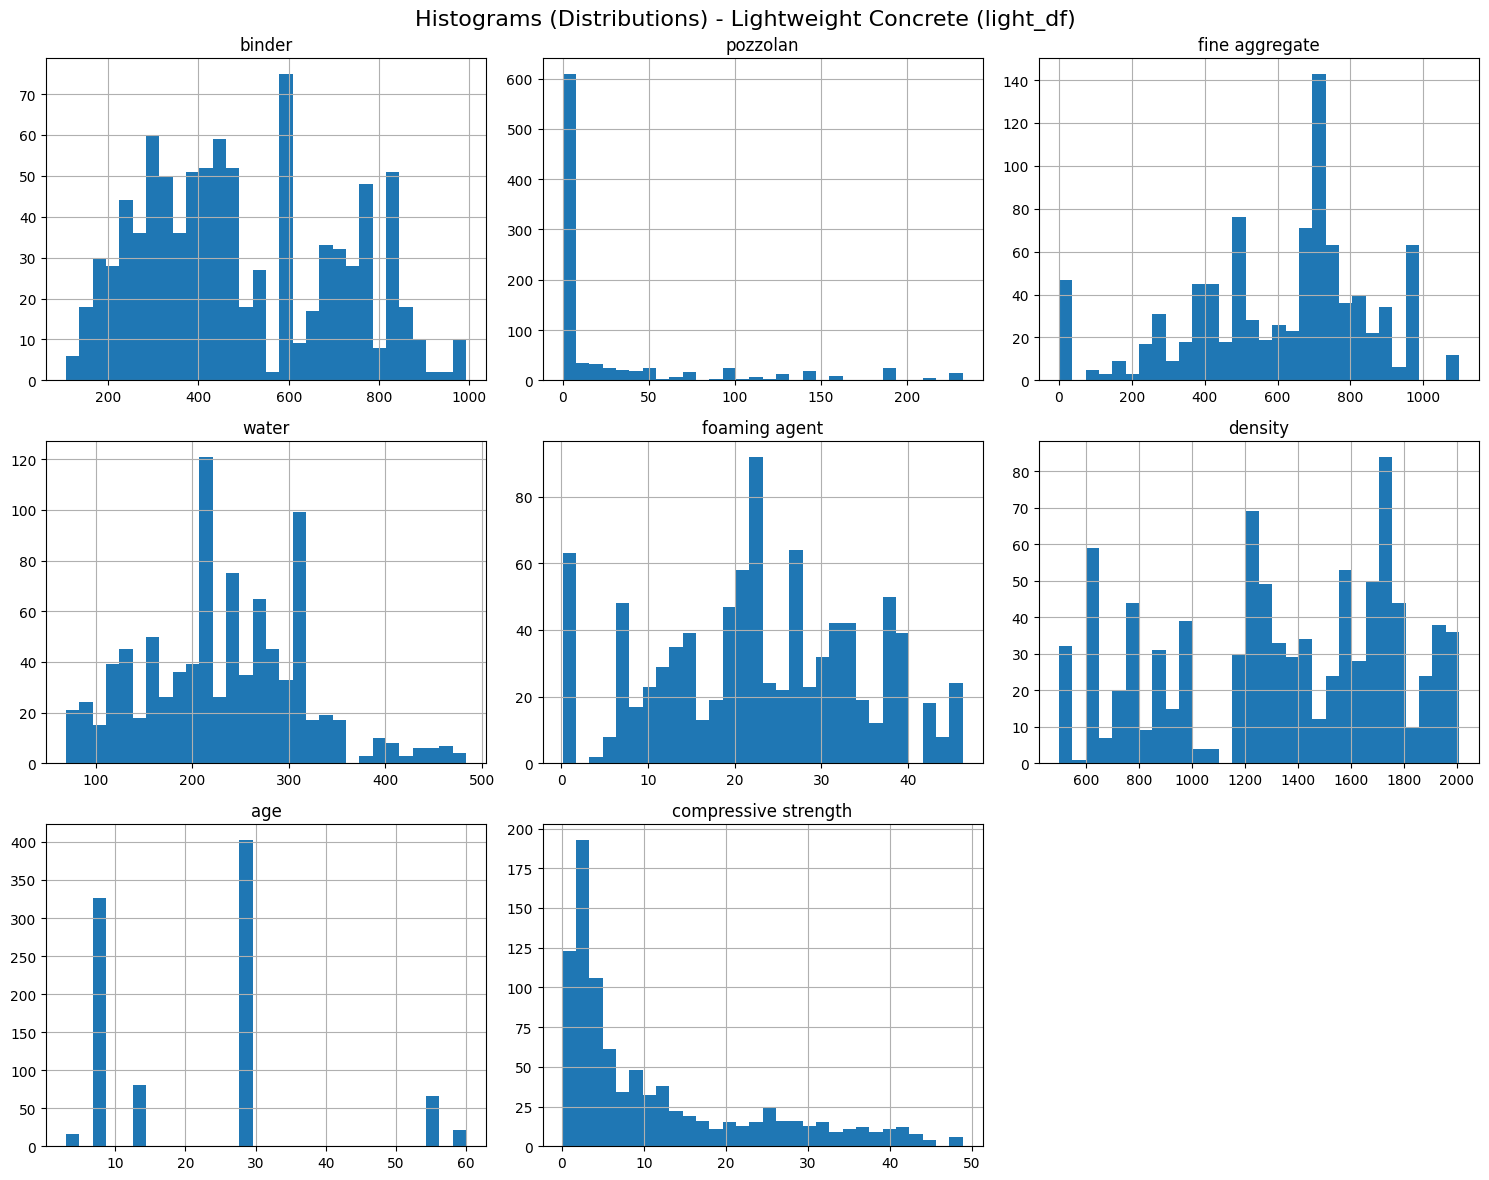

In [18]:
clean_light_df = light_df.copy()
print(f"Lightweight original: {len(clean_light_df)} rows")

clean_light_df = clean_light_df[clean_light_df['age'] < 175]
clean_light_df = clean_light_df[clean_light_df['pozzolan'] <= 250]
clean_light_df = clean_light_df[clean_light_df['fine aggregate'] < 1100]
clean_light_df = clean_light_df[(clean_light_df['density'] > 400) & (clean_light_df['density'] <= 2200)]
clean_light_df = clean_light_df[clean_light_df['binder'] > 0]
clean_light_df = clean_light_df[clean_light_df['compressive strength'] > 0]
clean_light_df = clean_light_df[clean_light_df['foaming agent'] < 50]

print(f"Lightweight after cleaning: {len(clean_light_df)} rows\n")

analyze_dataset(clean_light_df, "Lightweight Concrete (light_df)")

In [19]:
import numpy as np

all_columns = [
    "binder","extra water","water","alkaline solution","molarity of mix",
    "fine aggregate","coarse aggregate","pozzolan","foaming agent",
    "density","age","curing temperature","compressive strength"
]

for col in all_columns:
    if col not in clean_geo_df.columns:
        clean_geo_df[col] = np.nan

    if col not in clean_light_df.columns:
        clean_light_df[col] = np.nan

In [20]:
clean_geo_df.columns

Index(['binder', 'extra water', 'alkaline solution', 'molarity of mix',
       'fine aggregate', 'coarse aggregate', 'age', 'curing temperature',
       'compressive strength', 'water', 'pozzolan', 'foaming agent',
       'density'],
      dtype='object')

In [21]:
clean_light_df.columns

Index(['binder', 'pozzolan', 'fine aggregate', 'water', 'foaming agent',
       'density', 'age', 'compressive strength', 'extra water',
       'alkaline solution', 'molarity of mix', 'coarse aggregate',
       'curing temperature'],
      dtype='object')

In [22]:
clean_geo_df["concrete type"] = 0 # geopolymer
clean_light_df["concrete type"] = 1 # lightweight

In [23]:
combined_df = pd.concat([clean_geo_df, clean_light_df], ignore_index=True)

In [24]:
combined_df['water binder ratio'] = (
    combined_df['water'].fillna(0) + 
    combined_df['extra water'].fillna(0) + 
    combined_df['alkaline solution'].fillna(0)
) / combined_df['binder'].replace(0, np.nan)

In [25]:
combined_df['concrete type'] = combined_df['concrete type'].astype('category')

In [26]:
print(combined_df.shape)
print()
print(combined_df.isnull().sum())
print()
print(combined_df.dtypes)

(2603, 15)

binder                     0
extra water              912
alkaline solution        912
molarity of mix          912
fine aggregate             0
coarse aggregate         912
age                        0
curing temperature       912
compressive strength       0
water                   1691
pozzolan                1691
foaming agent           1691
density                 1691
concrete type              0
water binder ratio         0
dtype: int64

binder                   float64
extra water              float64
alkaline solution        float64
molarity of mix          float64
fine aggregate           float64
coarse aggregate         float64
age                      float64
curing temperature       float64
compressive strength     float64
water                    float64
pozzolan                 float64
foaming agent            float64
density                  float64
concrete type           category
water binder ratio       float64
dtype: object


In [27]:
combined_df.describe().T

,count,mean,std,min,25%,50%,75%,max
binder,2603.0,444.384456,136.453127,107.200000,400.000000,405.000000,468.000000,992.800000
extra water,1691.0,17.955802,26.448564,0.000000,0.000000,0.000000,32.000000,128.570000
alkaline solution,1691.0,187.283390,36.738527,106.680000,160.020000,180.000000,200.000000,294.400000
molarity of mix,1691.0,11.519456,2.776044,4.100000,10.000000,12.000000,14.000000,20.000000
fine aggregate,2603.0,631.456558,178.733070,0.000000,552.000000,645.000000,697.400000,1098.000000
coarse aggregate,1691.0,1099.968297,188.269756,647.800000,989.500000,1181.000000,1220.350000,1369.000000
age,2603.0,25.479447,22.430057,1.000000,7.000000,28.000000,28.000000,91.000000
curing temperature,1691.0,34.972797,16.904233,20.000000,27.000000,27.000000,28.000000,80.000000
compressive strength,2603.0,29.233115,21.240386,0.080000,10.390000,26.700000,43.717130,110.000000
water,912.0,233.005640,84.116711,68.900000,169.000000,234.000000,290.521250,484.000000


In [28]:
combined_df.head()

,binder,extra water,alkaline solution,molarity of mix,fine aggregate,coarse aggregate,age,curing temperature,compressive strength,water,pozzolan,foaming agent,density,concrete type,water binder ratio
0,428.0,43.0,171.0,14.0,630.0,1170.0,1.0,75.0,30.0,NaN,NaN,NaN,NaN,0,0.500000
1,444.0,43.0,155.0,14.0,630.0,1170.0,1.0,75.0,30.0,NaN,NaN,NaN,NaN,0,0.445946
2,428.0,43.0,171.0,14.0,630.0,1170.0,1.0,75.0,40.0,NaN,NaN,NaN,NaN,0,0.500000
3,428.0,43.0,171.0,14.0,630.0,1170.0,1.0,75.0,28.0,NaN,NaN,NaN,NaN,0,0.500000
4,428.0,43.0,171.0,14.0,630.0,1170.0,2.0,75.0,32.0,NaN,NaN,NaN,NaN,0,0.500000


--- Exploratory Data Analysis for lightweight and geopolymer concrete (combined_df) ---


<Figure size 1000x800 with 0 Axes>

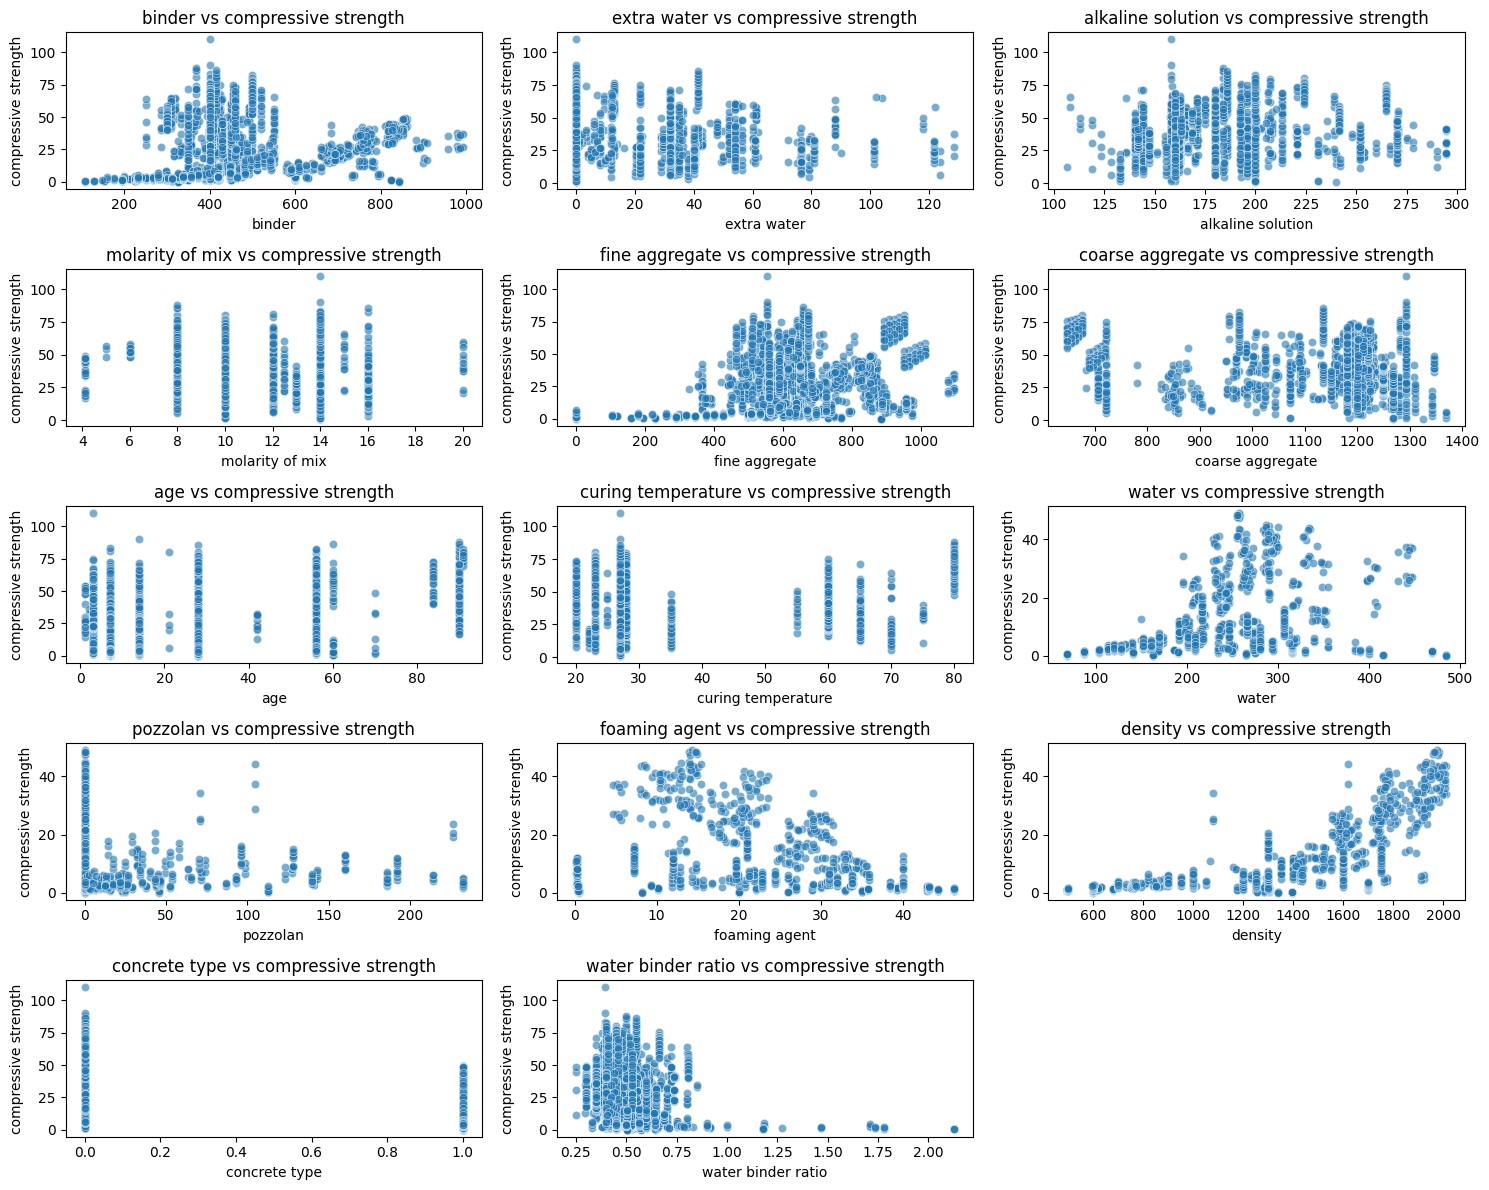

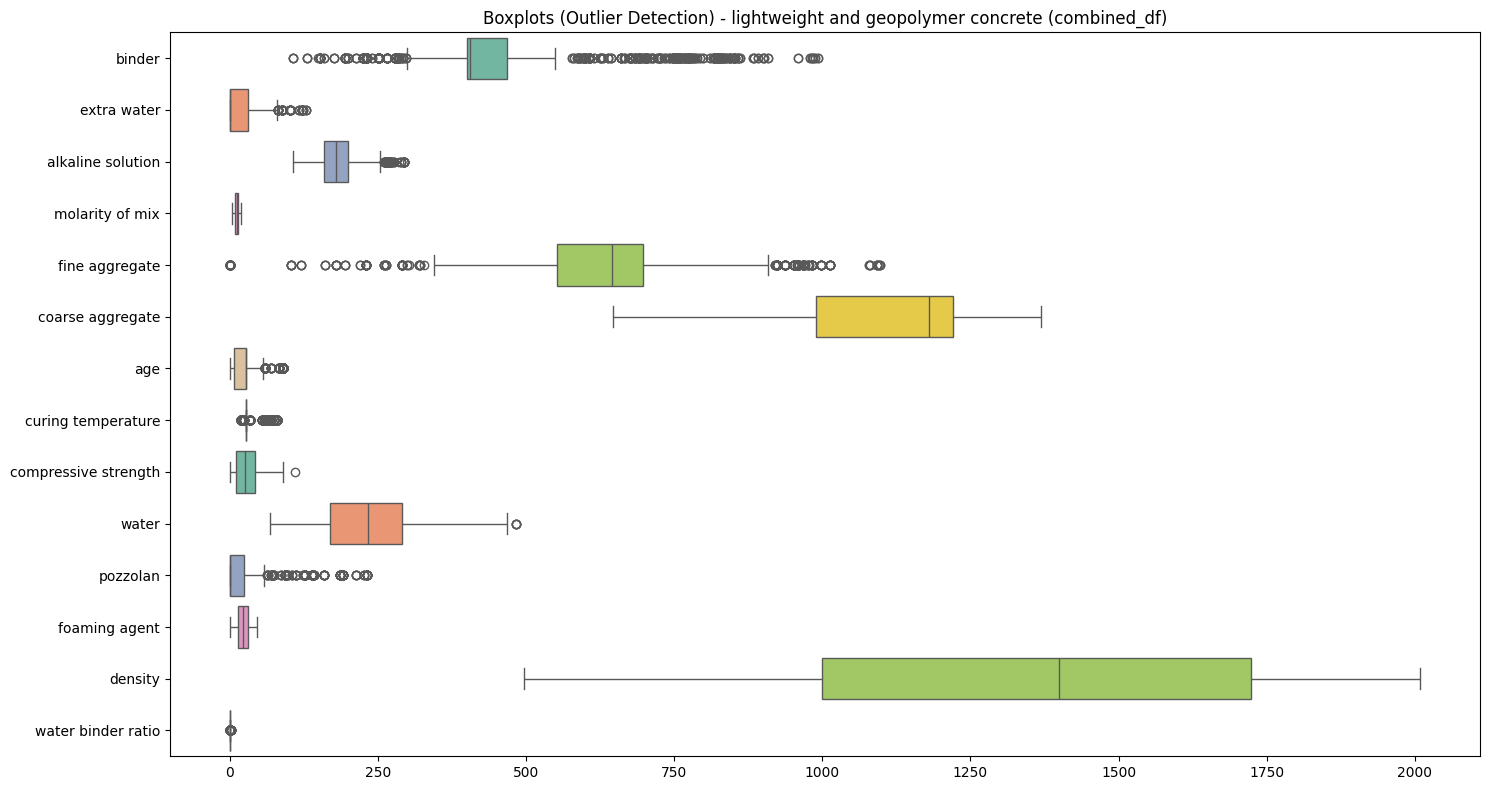

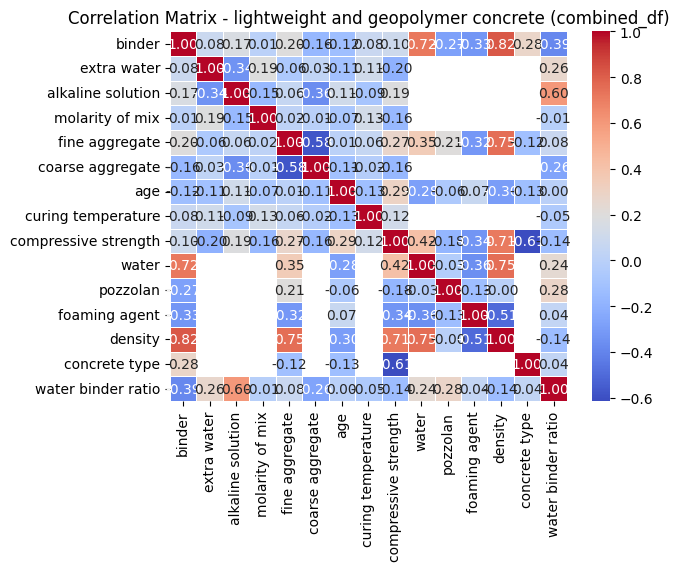

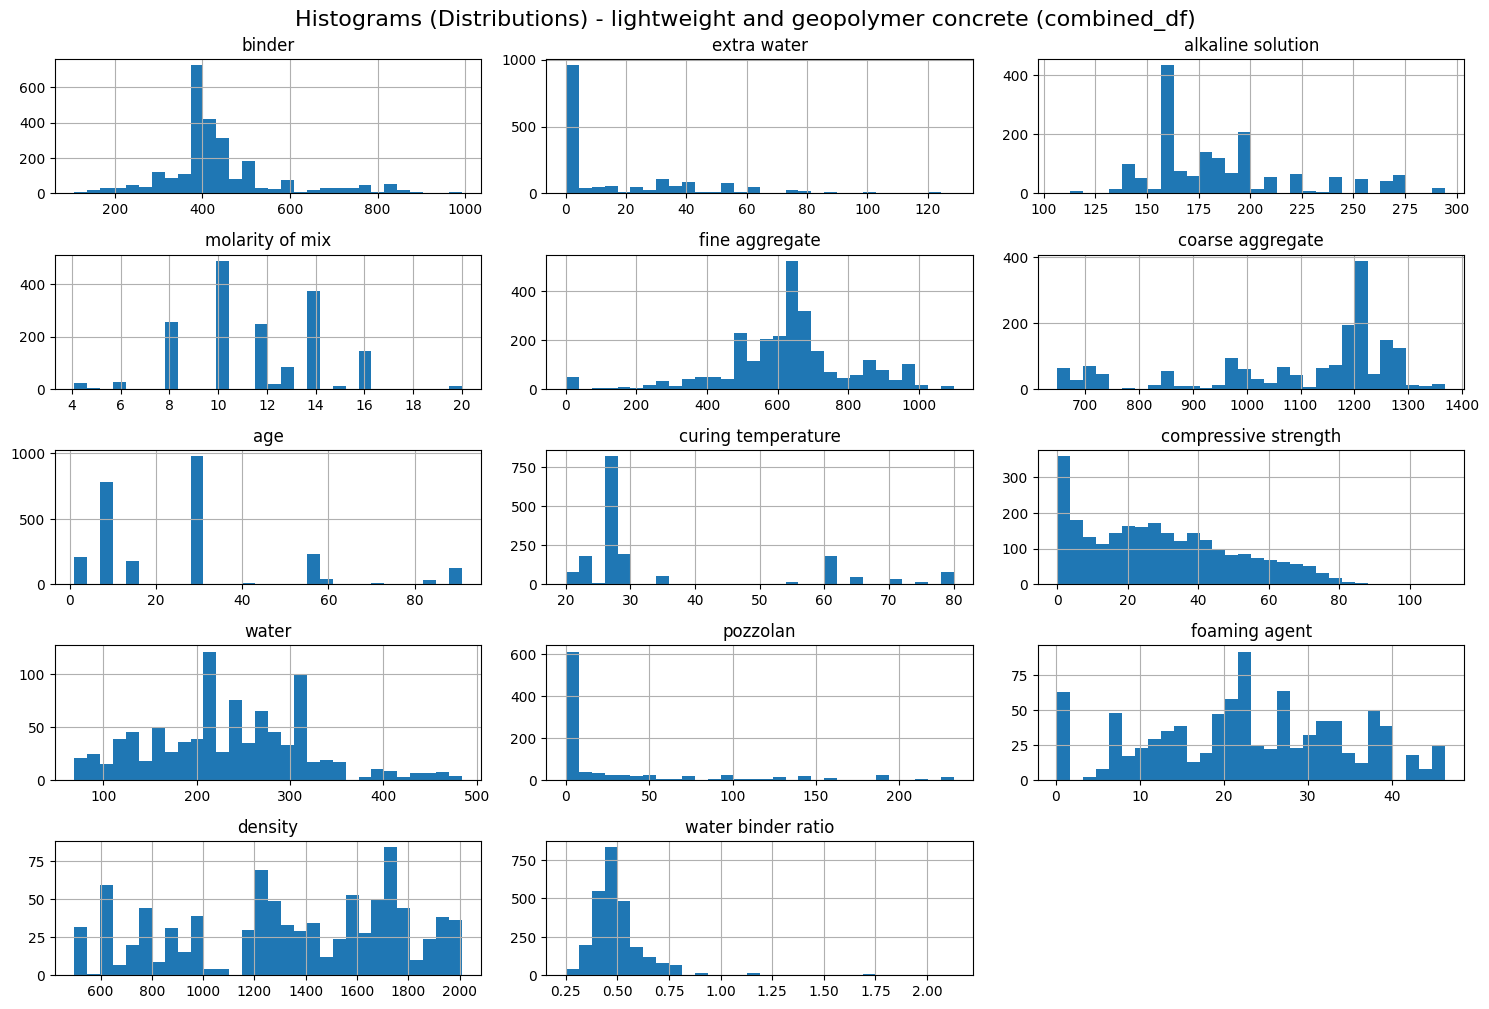

In [29]:
analyze_dataset(combined_df, "lightweight and geopolymer concrete (combined_df)")

In [32]:
combined_df = combined_df[combined_df['water binder ratio'] < 2]
print(combined_df.shape)
print(combined_df.isnull().sum())

(2600, 15)
binder                     0
extra water              909
alkaline solution        909
molarity of mix          909
fine aggregate             0
coarse aggregate         909
age                        0
curing temperature       909
compressive strength       0
water                   1691
pozzolan                1691
foaming agent           1691
density                 1691
concrete type              0
water binder ratio         0
dtype: int64


In [33]:
# saving the cleaned datasets

combined_df.to_csv("combined_concrete_data.csv", index=False)